In [ ]:
import duckdb, os
from datetime import datetime

# Reuse EMS_PATH and OUT_DIR from your session. If they’re not defined, re-find the EMS path quickly:
try:
    EMS_PATH
    OUT_DIR
except NameError:
    import os
    def walk_files(root="/content/drive", max_files=200000):
        n=0
        for dp,_,fns in os.walk(root):
            for fn in fns:
                n+=1
                if n>max_files: return
                yield os.path.join(dp,fn)
    EMS_BASENAME = "EMS_Incident_Dispatch_Data.csv"
    ems_paths = []
    for p in walk_files("/content/drive"):
        if os.path.basename(p) == EMS_BASENAME:
            try: sz = os.path.getsize(p)
            except: sz = 0
            ems_paths.append((p,sz))
    assert ems_paths, "EMS_Incident_Dispatch_Data.csv not found on Drive."
    ems_paths.sort(key=lambda x:x[1], reverse=True)
    EMS_PATH = ems_paths[0][0]
    OUT_DIR = os.path.dirname(EMS_PATH)
    print("Using EMS:", EMS_PATH)

MH_CODES = ("EDP","ALTMEN","ALTMFC","ALTMFT","JUMPDN","JUMPUP","JUMPDC","OD","ODC","POISON","DRUG")

TRUTHY  = ("Y","YES","TRUE","1")

# Robust parse: try multiple datetime formats
sql = f"""
PRAGMA threads=4;

WITH ems_raw AS (
  SELECT
    incident_datetime,
    communitydistrict,
    final_call_type,
    incident_disposition_code,
    special_event_indicator,
    standby_indicator,
    transfer_indicator
  FROM read_csv_auto('{EMS_PATH}', all_varchar=true, sample_size=-1, ignore_errors=true)
),
ems AS (
  SELECT
    /* Try common formats: 'YYYY-MM-DD HH:MM:SS' and ISO 'YYYY-MM-DDTHH:MM:SS' */
    COALESCE(
      try_strptime(incident_datetime, '%Y-%m-%d %H:%M:%S'),
      try_strptime(incident_datetime, '%Y-%m-%dT%H:%M:%S'),
      try_strptime(incident_datetime, '%m/%d/%Y %H:%M:%S'),
      try_strptime(incident_datetime, '%m/%d/%Y %I:%M:%S %p')
    ) AS incident_ts,
    try_cast(communitydistrict AS INTEGER)                       AS communitydistrict,
    upper(trim(final_call_type))                                 AS final_call_type,
    upper(trim(incident_disposition_code))                       AS disp_str,
    try_cast(incident_disposition_code AS INTEGER)               AS disp_int,
    upper(nullif(trim(special_event_indicator),''))              AS special_event_indicator,
    upper(nullif(trim(standby_indicator),''))                    AS standby_indicator,
    upper(nullif(trim(transfer_indicator),''))                   AS transfer_indicator
  FROM ems_raw
),
ems_filtered AS (
  SELECT *
  FROM ems
  WHERE (special_event_indicator NOT IN {TRUTHY} OR special_event_indicator IS NULL)
    AND (standby_indicator       NOT IN {TRUTHY} OR standby_indicator IS NULL)
    AND (transfer_indicator      NOT IN {TRUTHY} OR transfer_indicator IS NULL)
    AND (disp_str NOT IN ('CANCEL','NOTSNT','DUP') OR disp_str IS NULL)
    AND (disp_int IS NULL OR disp_int <> 87)
    AND incident_ts IS NOT NULL
),
panel AS (
  SELECT
    CAST(date_trunc('day', incident_ts) AS DATE)         AS incident_date,
    communitydistrict,
    COUNT(*)                                             AS total_calls,
    SUM(CASE WHEN final_call_type IN {MH_CODES} THEN 1 ELSE 0 END) AS mh_calls
  FROM ems_filtered
  GROUP BY 1,2
)
SELECT
  incident_date,
  communitydistrict,
  total_calls,
  mh_calls,
  CASE WHEN total_calls>0 THEN mh_calls::DOUBLE/total_calls::DOUBLE ELSE NULL END AS mh_share
FROM panel
ORDER BY incident_date, communitydistrict;
"""

con = duckdb.connect()
panel_df = con.execute(sql).fetch_df()
print("Panel shape:", panel_df.shape)
display(panel_df.head())

panel_parquet = os.path.join(OUT_DIR, "panel_cd_day.parquet")
panel_df.to_parquet(panel_parquet, index=False)
print("Wrote panel:", panel_parquet)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Panel shape: (485113, 5)


,incident_date,communitydistrict,total_calls,mh_calls,mh_share
0,2005-01-01,101,24,3.0,0.125000
1,2005-01-01,102,59,13.0,0.220339
2,2005-01-01,103,114,23.0,0.201754
3,2005-01-01,104,141,30.0,0.212766
4,2005-01-01,105,118,28.0,0.237288


Wrote panel: /content/drive/MyDrive/panel_cd_day.parquet


In [ ]:
# ============================
# Cell B — Twitter merge, lags/controls, regression (with cluster fix + caution)
# Run AFTER Cell A (which writes panel_cd_day.parquet)
# ============================

import os, re
import pandas as pd
import numpy as np
import patsy
import statsmodels.api as sm
from pandas.tseries.holiday import USFederalHolidayCalendar

# ---- 1) Locate inputs on Drive ----
# Exact Twitter filenames you said you'd use
TW1_BASENAME = "211118_tweet_count_name_date_drive.csv"
TW2_BASENAME = "220126_final_daily_tweet_count_drive.csv"

def find_exact(basename):
    for dp, _, fns in os.walk("/content/drive"):
        if basename in fns:
            return os.path.join(dp, basename)
    return None

TW1_PATH = find_exact(TW1_BASENAME)
TW2_PATH = find_exact(TW2_BASENAME)
assert TW1_PATH and TW2_PATH, "Twitter CSVs not found on Drive with the given filenames."

# Panel written by Cell A
# If OUT_DIR is not in scope, infer it from where the panel parquet lives
PANEL_CANDIDATES = []
for dp, _, fns in os.walk("/content/drive"):
    if "panel_cd_day.parquet" in fns:
        PANEL_CANDIDATES.append(os.path.join(dp, "panel_cd_day.parquet"))
assert len(PANEL_CANDIDATES) >= 1, "panel_cd_day.parquet not found. Run Cell A first."
PANEL_PATH = sorted(PANEL_CANDIDATES, key=lambda p: os.path.getmtime(p))[-1]
OUT_DIR = os.path.dirname(PANEL_PATH)

print("Using panel:", PANEL_PATH)
print("Twitter file 1:", TW1_PATH)
print("Twitter file 2:", TW2_PATH)

# ---- 2) Load & combine Twitter daily awareness ----
def load_twitter_csv(path):
    df = pd.read_csv(path, dtype=str, low_memory=False)
    df.columns = [c.strip().lower() for c in df.columns]
    # pick date-like column
    for cand in ("date", "day", "created_at"):
        if cand in df.columns:
            date_col = cand
            break
    else:
        date_col = df.columns[0]
    df["date"] = pd.to_datetime(df[date_col], errors="coerce").dt.date

    # pick count column (or create one)
    for cand in ("count", "tweet_count", "tweets", "n", "value", "total"):
        if cand in df.columns:
            cnt_col = cand
            break
    else:
        cnt_col = "count"
        df[cnt_col] = 1

    df[cnt_col] = pd.to_numeric(df[cnt_col], errors="coerce")
    out = (df.groupby("date", as_index=False)[cnt_col]
             .sum()
             .rename(columns={cnt_col: "tweet_count"}))
    return out.sort_values("date")

aware1 = load_twitter_csv(TW1_PATH)
aware2 = load_twitter_csv(TW2_PATH)

awareness = aware1.merge(aware2, on="date", how="outer", suffixes=("", "_2"))
tweet_cols = [c for c in awareness.columns if c.startswith("tweet_count")]
awareness["tweet_count_all"] = awareness[tweet_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
awareness = awareness[["date", "tweet_count_all"]].sort_values("date").reset_index(drop=True)
awareness["awareness_z"] = (awareness["tweet_count_all"] - awareness["tweet_count_all"].mean()) / awareness["tweet_count_all"].std(ddof=0)

print("Awareness preview:")
display(awareness.head())

# ---- 3) Merge awareness to panel & build lags ----
panel = pd.read_parquet(PANEL_PATH)
panel["incident_date"] = pd.to_datetime(panel["incident_date"])
awareness["date"] = pd.to_datetime(awareness["date"])

df_panel = panel.merge(awareness, left_on="incident_date", right_on="date", how="left").drop(columns=["date"])
df_panel = df_panel.sort_values(["communitydistrict", "incident_date"]).reset_index(drop=True)

max_lag = 28
for k in range(0, max_lag + 1):
    df_panel[f"awarez_lag{k}"] = df_panel.groupby("communitydistrict")["awareness_z"].shift(k)

# Controls
df_panel["dow"]   = df_panel["incident_date"].dt.dayofweek
df_panel["month"] = df_panel["incident_date"].dt.month
df_panel["year"]  = df_panel["incident_date"].dt.year
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=str(df_panel["incident_date"].min()),
                        end=str(df_panel["incident_date"].max()))
df_panel["is_holiday"] = df_panel["incident_date"].isin(holidays).astype(int)

d = df_panel["incident_date"]
df_panel["covid_phase"] = np.select(
    [
        (d >= pd.to_datetime("2020-03-01")) & (d <= pd.to_datetime("2020-06-30")),
        (d >= pd.to_datetime("2020-07-01"))
    ],
    [1, 2],
    default=0
)

print("Merged panel sample:")
display(df_panel.head())

# ---- 4) Distributed-lag regression on mh_share (with cluster SEs & alignment caution) ----
# Use a compact lag set for readability; expand if you like
lag_use  = [0, 1, 2, 3, 7, 14, 21, 28]
lag_cols = [f"awarez_lag{k}" for k in lag_use]

# Keep rows where DV exists AND at least one lag is non-missing
df_model = df_panel[df_panel["total_calls"] >= 5].copy()
df_model = df_model.dropna(subset=["mh_share"])
df_model = df_model.loc[df_model[lag_cols].notna().any(axis=1)].copy()

formula = "mh_share ~ " + " + ".join(lag_cols) + " + C(dow) + C(month):C(year) + is_holiday + C(covid_phase)"
y, X = patsy.dmatrices(formula, data=df_model, return_type="dataframe")

# IMPORTANT CAUTION: Align cluster groups exactly to the rows used by patsy (same index and order)
groups = df_model.loc[y.index, "communitydistrict"].astype("int64")

model = sm.OLS(y, X, missing="drop").fit(cov_type="cluster", cov_kwds={"groups": groups})

# Sanity assertion: groups length must equal the number of observations used by the model
assert len(groups) == int(model.nobs), "Cluster groups vector length does not match model nobs."

print(model.summary().as_text()[:2000])

# ---- 5) Save outputs next to the panel ----
panel_out  = os.path.join(OUT_DIR, "panel_cd_day_awareness.parquet")
params_out = os.path.join(OUT_DIR, "dl_model_params.csv")
df_panel.to_parquet(panel_out, index=False)
(model.params.rename("coef").to_frame()
       .join(model.bse.rename("se"))
       .to_csv(params_out))

print("\nSaved:")
print(" -", panel_out)
print(" -", params_out)


Using panel: /content/drive/MyDrive/panel_cd_day.parquet
Twitter file 1: /content/drive/MyDrive/211118_tweet_count_name_date_drive.csv
Twitter file 2: /content/drive/MyDrive/220126_final_daily_tweet_count_drive.csv
Awareness preview:


,date,tweet_count_all,awareness_z
0,2017-01-01,164,-0.203803
1,2017-01-02,140,-0.212995
2,2017-01-03,162,-0.204569
3,2017-01-04,180,-0.197674
4,2017-01-05,216,-0.183886


Merged panel sample:


,incident_date,communitydistrict,total_calls,mh_calls,mh_share,tweet_count_all,awareness_z,awarez_lag0,awarez_lag1,awarez_lag2,...,awarez_lag24,awarez_lag25,awarez_lag26,awarez_lag27,awarez_lag28,dow,month,year,is_holiday,covid_phase
0,2005-01-01,101,24,3.0,0.125000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,1,2005,0,0
1,2005-01-02,101,13,1.0,0.076923,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6,1,2005,0,0
2,2005-01-03,101,34,7.0,0.205882,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,1,2005,0,0
3,2005-01-04,101,39,5.0,0.128205,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,2005,0,0
4,2005-01-05,101,29,4.0,0.137931,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,2005,0,0


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 76, but rank is 62
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:               mh_share   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     455.6
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.19e-70
Time:                        06:35:42   Log-Likelihood:             1.1983e+05
No. Observations:               85139   AIC:                        -2.395e+05
Df Residuals:                   85076   BIC:                        -2.390e+05
Df Model:                          62                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [ ]:
# --------------------------
# CD fixed effects version (with dtype fix)
# --------------------------
import os
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm

# Use the same df_panel created earlier
lag_use  = [0, 1, 2, 3, 7, 14, 21, 28]
lag_cols = [f"awarez_lag{k}" for k in lag_use]

# Filter to usable rows
df_fe = df_panel[df_panel["total_calls"] >= 5].copy()
df_fe = df_fe.dropna(subset=["mh_share", "communitydistrict"])
df_fe = df_fe.loc[df_fe[lag_cols].notna().any(axis=1)].copy()

# >>> FIX: Convert communitydistrict to plain int for clustering,
# and to string for categorical fixed effects
df_fe["cd_int"] = df_fe["communitydistrict"].astype("int64")
df_fe["cd_str"] = df_fe["cd_int"].astype(str)

# Model with CD fixed effects via C(cd_str)
formula_fe = (
    "mh_share ~ "
    + " + ".join(lag_cols)
    + " + C(dow) + C(month):C(year) + is_holiday + C(covid_phase) + C(cd_str)"
)

y_fe, X_fe = patsy.dmatrices(formula_fe, data=df_fe, return_type="dataframe")

# Align cluster groups to the rows actually used by Patsy
groups = df_fe.loc[y_fe.index, "cd_int"].to_numpy(dtype="int64")

mod_fe = sm.OLS(y_fe, X_fe, missing="drop").fit(
    cov_type="cluster", cov_kwds={"groups": groups}
)

# Caution check: groups length must match model nobs
assert len(groups) == int(mod_fe.nobs), "Cluster groups length mismatch."

print(mod_fe.summary().as_text()[:2000])

# Save parameters
params_fe = (
    mod_fe.params.rename("coef").to_frame()
    .join(mod_fe.bse.rename("se"))
)
params_fe.to_csv(os.path.join(OUT_DIR, "dl_model_params_with_cdfe.csv"))
print("Saved:", os.path.join(OUT_DIR, "dl_model_params_with_cdfe.csv"))


                            OLS Regression Results                            
Dep. Variable:               mh_share   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                 1.259e+05
Date:                Tue, 21 Oct 2025   Prob (F-statistic):          2.25e-152
Time:                        06:39:55   Log-Likelihood:             1.2743e+05
No. Observations:               85139   AIC:                        -2.546e+05
Df Residuals:                   85009   BIC:                        -2.534e+05
Df Model:                         129                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 143, but rank is 62
  warnings.warn('covariance of constraints does not have full '


,lag,coef,se,ci_lo,ci_hi
0,0,0.000500,0.000331,-0.000148,0.001148
1,1,-0.000678,0.000390,-0.001442,0.000086
2,2,-0.000352,0.000420,-0.001176,0.000472
3,3,-0.000082,0.000411,-0.000888,0.000724
4,7,0.001387,0.000378,0.000647,0.002127
5,14,0.000536,0.000264,0.000018,0.001054
6,21,-0.000008,0.000258,-0.000513,0.000497
7,28,0.000393,0.000205,-0.000008,0.000795


Saved: /content/drive/MyDrive/ir_mhshare_cdfe.csv 
Saved: /content/drive/MyDrive/ir_mhshare_cdfe.png


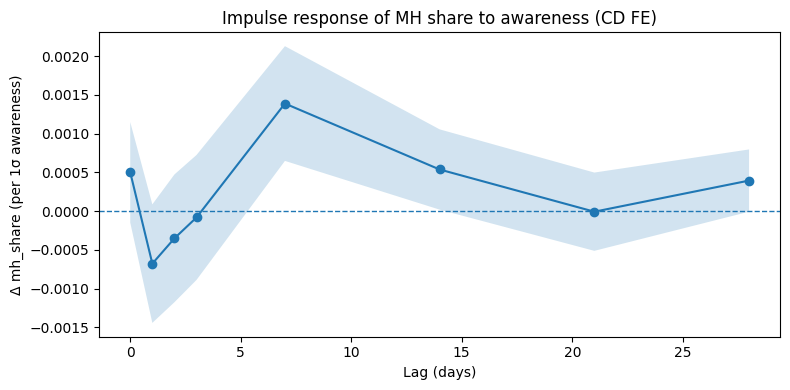

In [ ]:
# --- Impulse response from the CD-FE model you just fit (mod_fe) ---
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pull lag betas and CIs
lag_re = re.compile(r"^awarez_lag(\d+)$")
rows = []
for name, coef in mod_fe.params.items():
    m = lag_re.match(name)
    if m:
        k = int(m.group(1))
        se = mod_fe.bse[name]
        ci_lo, ci_hi = mod_fe.conf_int().loc[name].tolist()
        rows.append((k, coef, se, ci_lo, ci_hi))

ir = pd.DataFrame(rows, columns=["lag","coef","se","ci_lo","ci_hi"]).sort_values("lag")
display(ir)

# plot
plt.figure(figsize=(8,4))
plt.axhline(0, lw=1, ls="--")
plt.plot(ir["lag"], ir["coef"], marker="o")
plt.fill_between(ir["lag"], ir["ci_lo"], ir["ci_hi"], alpha=0.2)
plt.title("Impulse response of MH share to awareness (CD FE)")
plt.xlabel("Lag (days)")
plt.ylabel("Δ mh_share (per 1σ awareness)")
plt.tight_layout()

# save
ir_path = os.path.join(OUT_DIR, "ir_mhshare_cdfe.csv")
png_path = os.path.join(OUT_DIR, "ir_mhshare_cdfe.png")
ir.to_csv(ir_path, index=False)
plt.savefig(png_path, dpi=180)
print("Saved:", ir_path, "\nSaved:", png_path)


In [ ]:
# --- Patched helper: DL with CD fixed effects for any DV (NA-safe) ---
import pandas as pd
import patsy, statsmodels.api as sm

lag_use  = [0,1,2,3,7,14,21,28]
lag_cols = [f"awarez_lag{k}" for k in lag_use]

def run_dl_cdfe(df, dv):
    d = df.copy()

    # outcomes & exposure availability
    d = d[(d["total_calls"] >= 5) & d[dv].notna()]
    d = d.loc[d[lag_cols].notna().any(axis=1)]

    # --- FIX: ensure communitydistrict is clean int for clustering ---
    d["cd_int"] = pd.to_numeric(d["communitydistrict"], errors="coerce")
    d = d.dropna(subset=["cd_int"])          # drop rows with missing CD
    d["cd_int"] = d["cd_int"].astype("int64")
    d["cd_str"] = d["cd_int"].astype(str)    # string for C() fixed effects

    # stabilize scale for counts (cosmetic; doesn’t affect inference)
    if dv in ("mh_calls", "total_calls"):
        d[dv] = pd.to_numeric(d[dv], errors="coerce").astype(float) / 100.0

    formula = (
        f"{dv} ~ " + " + ".join(lag_cols)
        + " + C(dow) + C(month):C(year) + is_holiday + C(covid_phase) + C(cd_str)"
    )
    y, X = patsy.dmatrices(formula, data=d, return_type="dataframe")

    groups = d.loc[y.index, "cd_int"].to_numpy(dtype="int64")
    m = sm.OLS(y, X, missing="drop").fit(cov_type="cluster", cov_kwds={"groups": groups})

    # safety check
    assert len(groups) == int(m.nobs)
    return m


In [ ]:
mod_mh  = run_dl_cdfe(df_panel, "mh_calls")
mod_tot = run_dl_cdfe(df_panel, "total_calls")

print("\n=== MH calls (levels) ===")
print(mod_mh.summary().as_text()[:1600])

print("\n=== Total calls (placebo) ===")
print(mod_tot.summary().as_text()[:1600])

# save params
import os, pandas as pd
pd.concat({
    "mh_calls": mod_mh.params.rename("coef").to_frame().join(mod_mh.bse.rename("se")),
    "total":    mod_tot.params.rename("coef").to_frame().join(mod_tot.bse.rename("se"))
}, axis=0).to_csv(os.path.join(OUT_DIR, "dl_params_levels.csv"))
print("Saved:", os.path.join(OUT_DIR, "dl_params_levels.csv"))



=== MH calls (levels) ===
                            OLS Regression Results                            
Dep. Variable:               mh_calls   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                 1.397e+07
Date:                Tue, 21 Oct 2025   Prob (F-statistic):          6.90e-221
Time:                        06:43:37   Log-Likelihood:             1.6053e+05
No. Observations:               85139   AIC:                        -3.208e+05
Df Residuals:                   85009   BIC:                        -3.196e+05
Df Model:                         129                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 143, but rank is 62
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 143, but rank is 62
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:            total_calls   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                 1.503e+07
Date:                Tue, 21 Oct 2025   Prob (F-statistic):          5.87e-222
Time:                        06:43:38   Log-Likelihood:                 68220.
No. Observations:               85139   AIC:                        -1.362e+05
Df Residuals:                   85009   BIC:                        -1.350e+05
Df Model:                         129                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [ ]:
def cumulative_effect(model, lags=(0,1,2,3,4,5,6,7)):
    import numpy as np
    names = [f"awarez_lag{k}" for k in lags if f"awarez_lag{k}" in model.params.index]
    S  = model.params.loc[names].sum()
    VC = model.cov_params().loc[names, names].to_numpy()
    se = float(np.sqrt(VC.sum()))  # variance of sum = 1' V 1
    return S, se

cum_b, cum_se = cumulative_effect(mod_fe, lags=(0,1,2,3,4,5,6,7))
print(f"Cumulative β (0–7 days) on mh_share: {cum_b:.6f} ± {1.96*cum_se:.6f}")


Cumulative β (0–7 days) on mh_share: 0.000775 ± 0.000941


In [ ]:
# Convert cumulative effect on mh_share to calls per 1σ awareness
import numpy as np, pandas as pd, os

# use your cumulative estimate + variance
cum_b, cum_se = 0.000775, 0.000941  # replace with your printed numbers if they changed
city_mean_total = df_panel["total_calls"].mean()

def calls_from_share(beta, se, total):
    point = beta * total
    se_calls = se * total
    return point, 1.96*se_calls

# citywide
pt, ci = calls_from_share(cum_b, cum_se, city_mean_total)
print(f"Citywide: +{pt:.2f} MH calls over 0–7 days per 1σ awareness (±{ci:.2f})")

# by CD
cd_means = (df_panel.groupby("communitydistrict", as_index=False)
                    .agg(total_mean=("total_calls","mean")))
cd_means["delta_calls_pt"] = cum_b * cd_means["total_mean"]
cd_means["delta_calls_ci"] = 1.96 * cum_se * cd_means["total_mean"]
cd_means.sort_values("delta_calls_pt", ascending=False).to_csv(
    os.path.join(OUT_DIR, "delta_calls_by_cd.csv"), index=False
)
print("Saved:", os.path.join(OUT_DIR, "delta_calls_by_cd.csv"))


Citywide: +0.04 MH calls over 0–7 days per 1σ awareness (±0.10)
Saved: /content/drive/MyDrive/delta_calls_by_cd.csv
